# 04 - Error analysis and cross-task diagnostics

This notebook produces report-focused analysis artifacts:

- Per-class accuracy bars for Task 1 and Task 2
- Side-by-side confusion matrix comparisons (handcrafted vs CNN)
- Task 2 misclassified image grids for worst confusion pairs
- ResNet18 class-centroid cosine similarity heatmap (Task 2)
- Task 2 learning curves (handcrafted LR vs ResNet18 LR)

All figures are saved to `outputs/figures/error_analysis/`.

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from utils import evaluate, kfold, load_embedding_cache, load_task, seed_everything, stratified_split

SEED = 42
seed_everything(SEED)

OUT_DIR = REPO_ROOT / "outputs" / "figures" / "error_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

In [7]:
task1 = load_task(1)
task2 = load_task(2)

X1 = task1.X_handcrafted_train
y1 = task1.y_train
class_map1 = task1.class_mapping.sort_values("class_id").reset_index(drop=True)
class_ids1 = class_map1["class_id"].tolist()
class_names1 = class_map1["class_name"].tolist()

X2 = task2.X_handcrafted_train
y2 = task2.y_train
class_map2 = task2.class_mapping.sort_values("class_id").reset_index(drop=True)
class_ids2 = class_map2["class_id"].tolist()
class_names2 = class_map2["class_name"].tolist()

X1_resnet, ids1_resnet = load_embedding_cache(1, "train", "resnet18")
X2_resnet, ids2_resnet = load_embedding_cache(2, "train", "resnet18")

assert list(ids1_resnet) == list(task1.train_ids)
assert list(ids2_resnet) == list(task2.train_ids)


def per_class_accuracy(cm: np.ndarray) -> np.ndarray:
    row_sum = cm.sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        acc = np.where(row_sum > 0, np.diag(cm) / row_sum, 0.0)
    return acc


def fit_task1_holdout_preds(X_hand, X_resnet, y):
    Xh_tr, Xh_val, y_tr, y_val = stratified_split(X_hand, y, test_size=0.2, seed=SEED)
    Xr_tr, Xr_val, _, _ = stratified_split(X_resnet, y, test_size=0.2, seed=SEED)

    hand = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs", random_state=SEED)),
    ])
    cnn = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs", random_state=SEED)),
    ])

    hand.fit(Xh_tr, y_tr)
    cnn.fit(Xr_tr, y_tr)
    return y_val, hand.predict(Xh_val), cnn.predict(Xr_val)


def oof_task2_preds(X_hand, X_resnet, y):
    hand = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2500, C=1.0, solver="lbfgs", random_state=SEED)),
    ])
    cnn = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs", random_state=SEED)),
    ])

    cv = kfold(5, seed=SEED)
    hand_pred = cross_val_predict(hand, X_hand, y, cv=cv, method="predict", n_jobs=-1)
    cnn_pred = cross_val_predict(cnn, X_resnet, y, cv=cv, method="predict", n_jobs=-1)
    return hand_pred, cnn_pred

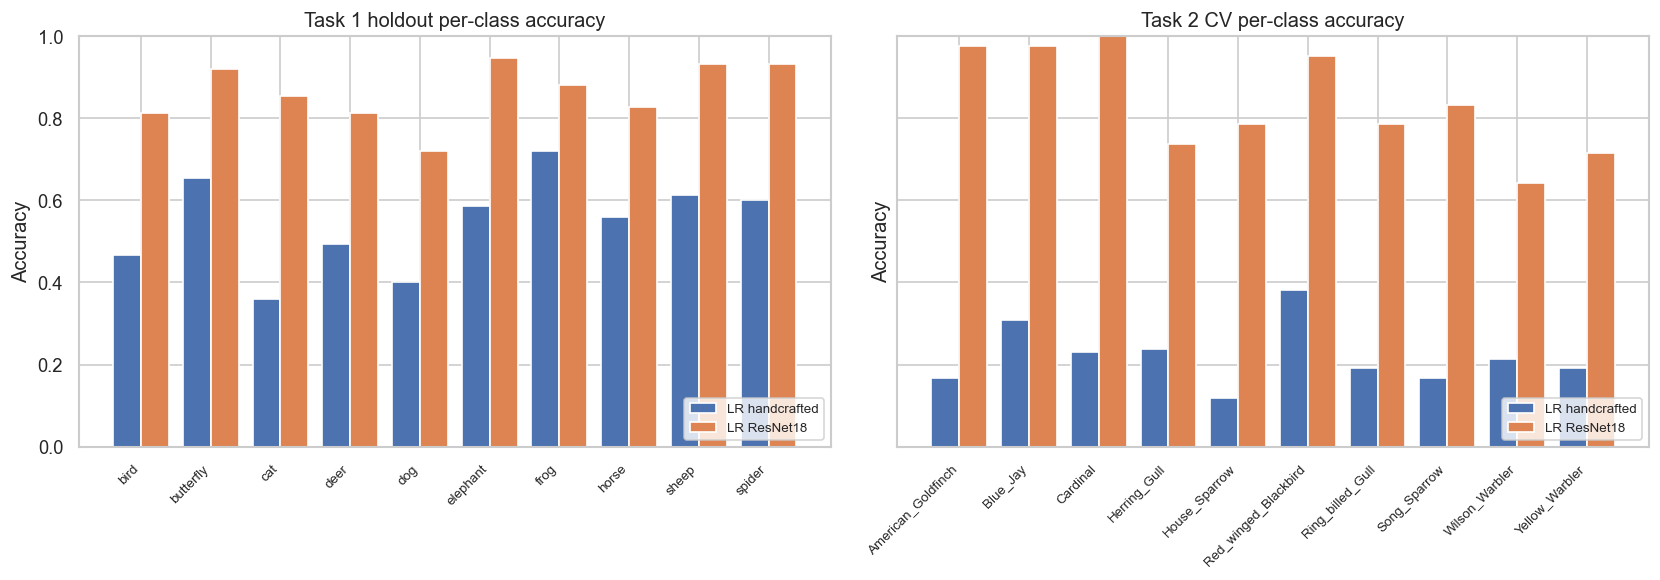

Saved /Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/per_class_accuracy_bars.png


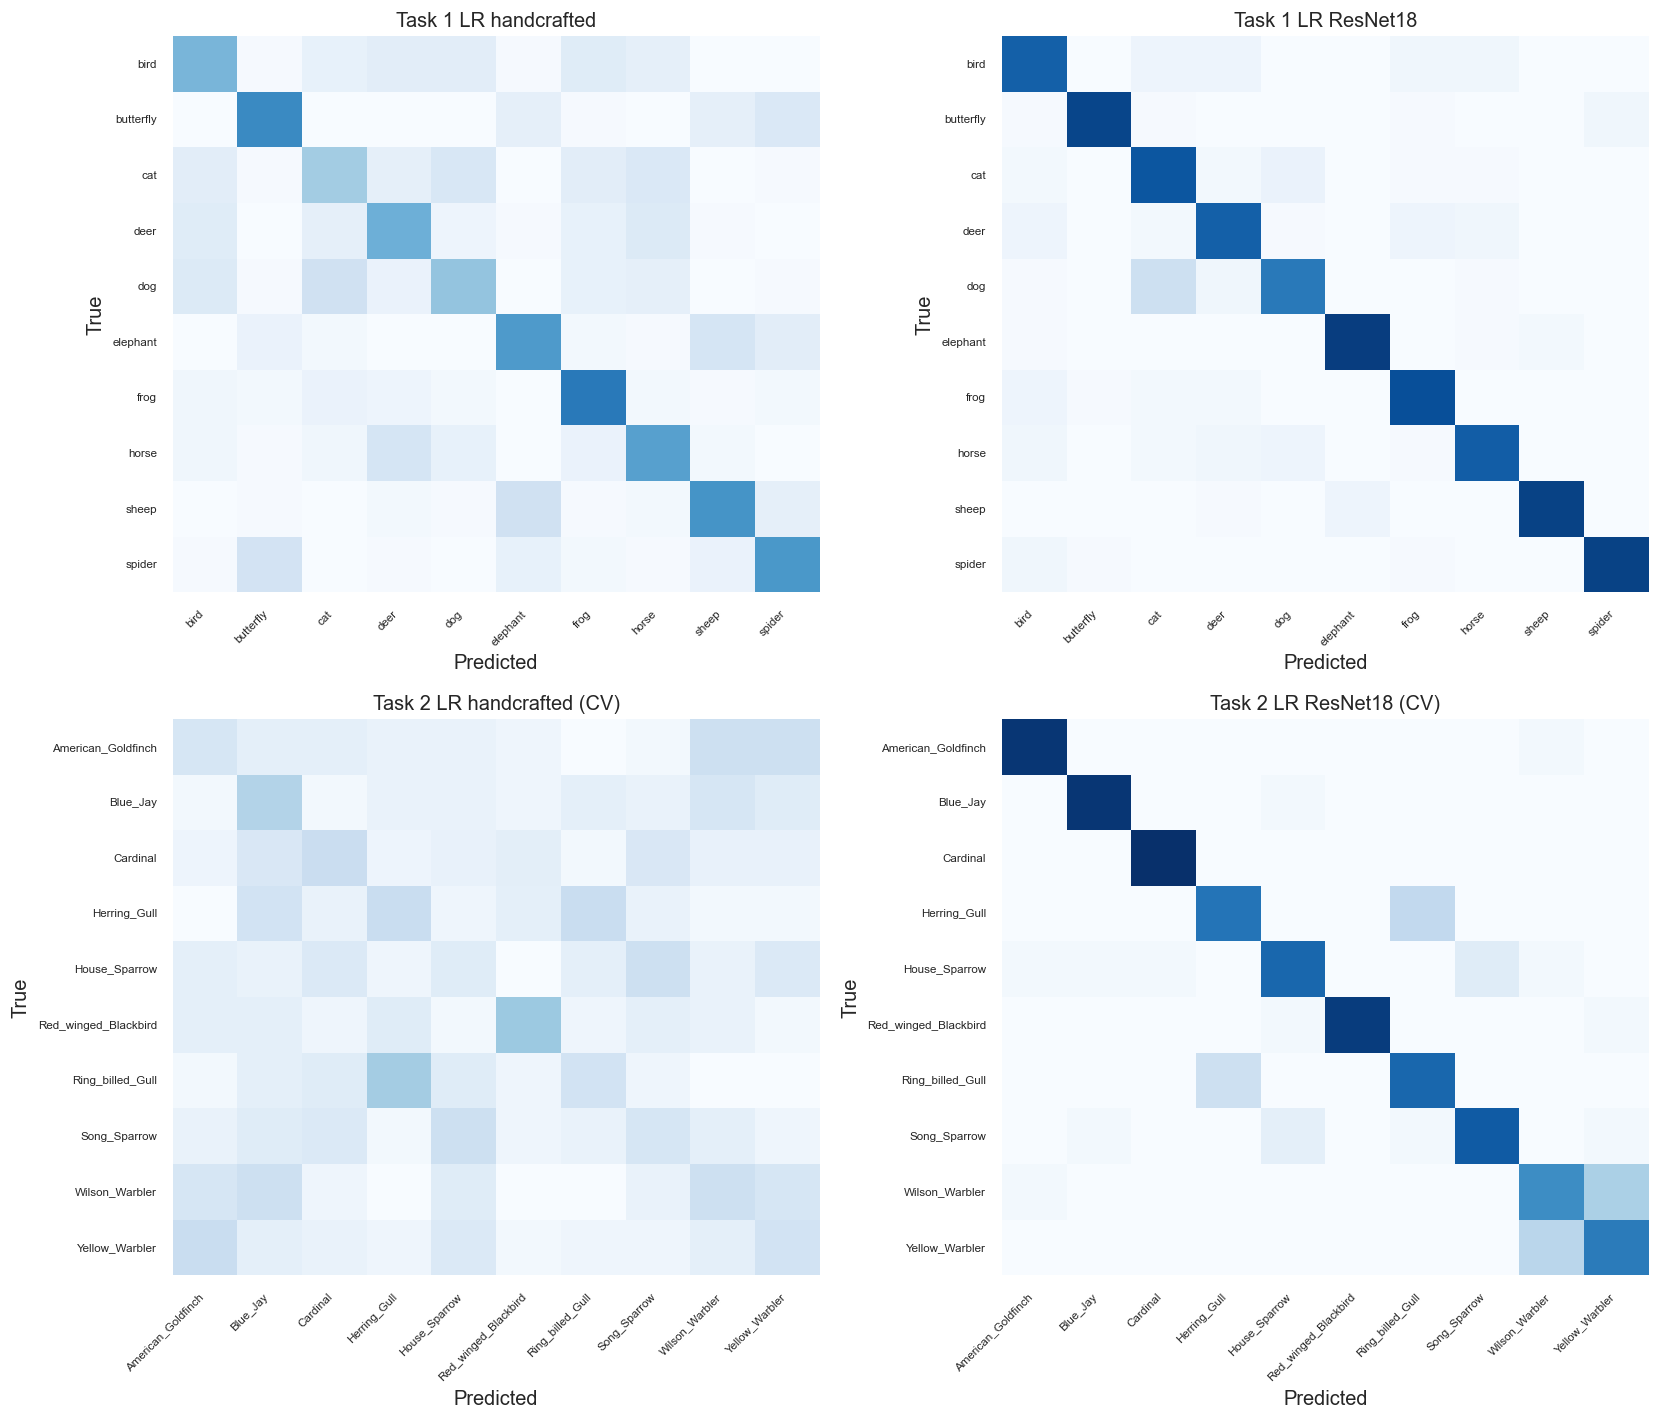

Saved /Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/side_by_side_confusions.png
Task 1 macro-F1 handcrafted vs ResNet18: 0.5421 -> 0.8651
Task 2 macro-F1 handcrafted vs ResNet18: 0.2217 -> 0.8408


In [8]:
# Task 1 holdout and Task 2 CV predictions

y1_val, y1_hand_pred, y1_cnn_pred = fit_task1_holdout_preds(X1, X1_resnet, y1)
y2_hand_pred, y2_cnn_pred = oof_task2_preds(X2, X2_resnet, y2)

m1_hand = evaluate(y1_val, y1_hand_pred, labels=class_ids1)
m1_cnn = evaluate(y1_val, y1_cnn_pred, labels=class_ids1)
m2_hand = evaluate(y2, y2_hand_pred, labels=class_ids2)
m2_cnn = evaluate(y2, y2_cnn_pred, labels=class_ids2)

# Per-class accuracy bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metrics_hand, metrics_cnn, names, title in [
    (axes[0], m1_hand, m1_cnn, class_names1, "Task 1 holdout per-class accuracy"),
    (axes[1], m2_hand, m2_cnn, class_names2, "Task 2 CV per-class accuracy"),
]:
    x = np.arange(len(names))
    acc_hand = per_class_accuracy(metrics_hand["confusion_matrix"])
    acc_cnn = per_class_accuracy(metrics_cnn["confusion_matrix"])
    ax.bar(x - 0.2, acc_hand, width=0.4, label="LR handcrafted")
    ax.bar(x + 0.2, acc_cnn, width=0.4, label="LR ResNet18")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel("Accuracy")
    ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
bar_path = OUT_DIR / "per_class_accuracy_bars.png"
fig.savefig(bar_path, bbox_inches="tight")
plt.show()
print(f"Saved {bar_path}")

# Side-by-side confusion matrix comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, cm, names, title in [
    (axes[0, 0], m1_hand["confusion_matrix"], class_names1, "Task 1 LR handcrafted"),
    (axes[0, 1], m1_cnn["confusion_matrix"], class_names1, "Task 1 LR ResNet18"),
    (axes[1, 0], m2_hand["confusion_matrix"], class_names2, "Task 2 LR handcrafted (CV)"),
    (axes[1, 1], m2_cnn["confusion_matrix"], class_names2, "Task 2 LR ResNet18 (CV)"),
]:
    cm = cm.astype(float)
    cm = np.where(cm.sum(axis=1, keepdims=True) > 0, cm / cm.sum(axis=1, keepdims=True), 0.0)
    sns.heatmap(cm, ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(names)) + 0.5)
    ax.set_yticks(np.arange(len(names)) + 0.5)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(names, rotation=0, fontsize=7)
fig.tight_layout()
cm_path = OUT_DIR / "side_by_side_confusions.png"
fig.savefig(cm_path, bbox_inches="tight")
plt.show()
print(f"Saved {cm_path}")

print("Task 1 macro-F1 handcrafted vs ResNet18:", round(m1_hand["macro_f1"], 4), "->", round(m1_cnn["macro_f1"], 4))
print("Task 2 macro-F1 handcrafted vs ResNet18:", round(m2_hand["macro_f1"], 4), "->", round(m2_cnn["macro_f1"], 4))

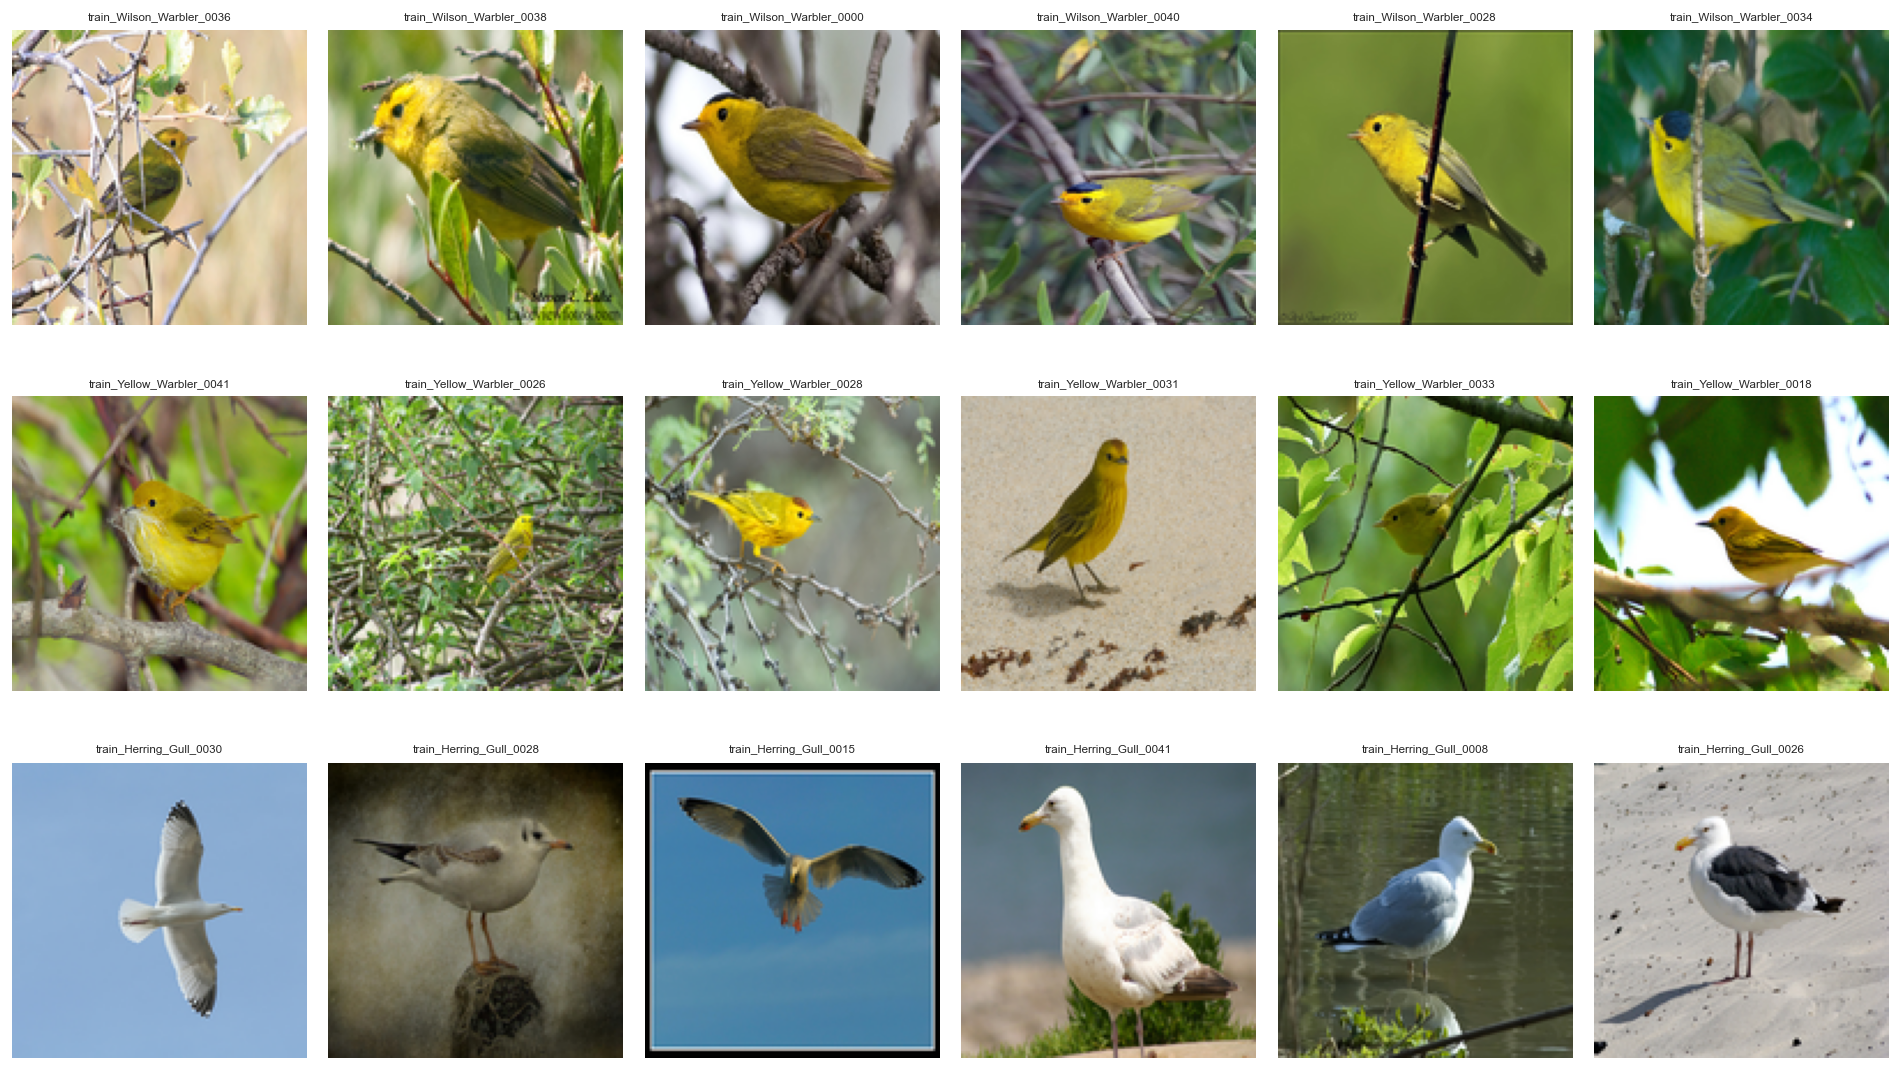

Saved /Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/task2_misclassified_grids.png


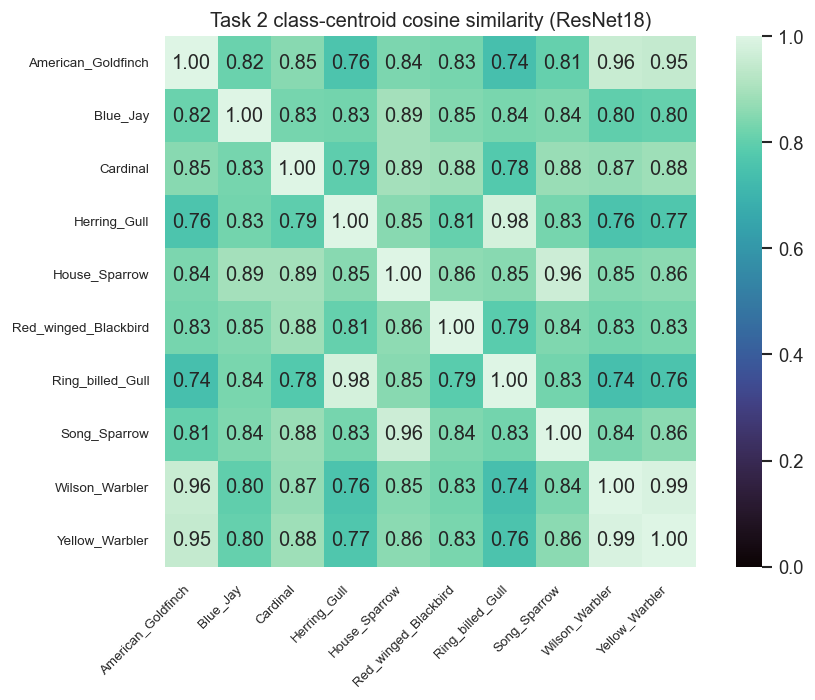

Saved /Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/task2_centroid_cosine_heatmap.png


In [9]:
# Task 2 misclassified grids for worst confusion pairs (from ResNet18 LR OOF predictions)

cm2 = m2_cnn["confusion_matrix"]
np.fill_diagonal(cm2, 0)
worst_pairs = np.dstack(np.unravel_index(np.argsort(cm2.ravel())[::-1], cm2.shape))[0][:3]

pred_series = pd.Series(y2_cnn_pred, index=task2.train_meta.index, name="pred")
meta2 = task2.train_meta.copy().reset_index(drop=True)
meta2["pred"] = pred_series.values

fig, axes = plt.subplots(len(worst_pairs), 6, figsize=(16, 3.2 * len(worst_pairs)))
if len(worst_pairs) == 1:
    axes = np.array([axes])

for row_idx, (true_id, pred_id) in enumerate(worst_pairs):
    subset = meta2[(meta2["class_id"] == int(true_id)) & (meta2["pred"] == int(pred_id))]
    label = f"true={class_names2[int(true_id)]} | pred={class_names2[int(pred_id)]}"

    if len(subset) == 0:
        for ax in axes[row_idx]:
            ax.axis("off")
        axes[row_idx, 0].text(0.0, 0.5, f"No samples for {label}", fontsize=10)
        continue

    picks = subset.sample(n=min(6, len(subset)), random_state=SEED + row_idx)
    for col in range(6):
        ax = axes[row_idx, col]
        if col < len(picks):
            rel = picks.iloc[col]["image_path"]
            with Image.open(task2.task_dir / rel) as im:
                ax.imshow(im.convert("RGB"))
            ax.set_title(f"{picks.iloc[col]['image_id']}", fontsize=7)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(label, fontsize=8)

fig.tight_layout()
mis_path = OUT_DIR / "task2_misclassified_grids.png"
fig.savefig(mis_path, bbox_inches="tight")
plt.show()
print(f"Saved {mis_path}")

# Task 2 centroid cosine similarity heatmap on ResNet18 embeddings
centroids = []
for cid in class_ids2:
    cls_emb = X2_resnet[y2 == cid]
    centroid = cls_emb.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-12)
    centroids.append(centroid)
centroids = np.vstack(centroids)
cos = centroids @ centroids.T

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cos, cmap="mako", vmin=0, vmax=1, square=True, annot=True, fmt=".2f", ax=ax)
ax.set_title("Task 2 class-centroid cosine similarity (ResNet18)")
ax.set_xticklabels(class_names2, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(class_names2, rotation=0, fontsize=8)
fig.tight_layout()
cos_path = OUT_DIR / "task2_centroid_cosine_heatmap.png"
fig.savefig(cos_path, bbox_inches="tight")
plt.show()
print(f"Saved {cos_path}")

## Extra visual inspection grids

The grids below save labelled examples from targeted error pairs so the image-level reasons for common confusions can be inspected manually. Task 2 uses ResNet18 LR out-of-fold predictions, while Task 1 uses the ResNet18 LR holdout predictions.


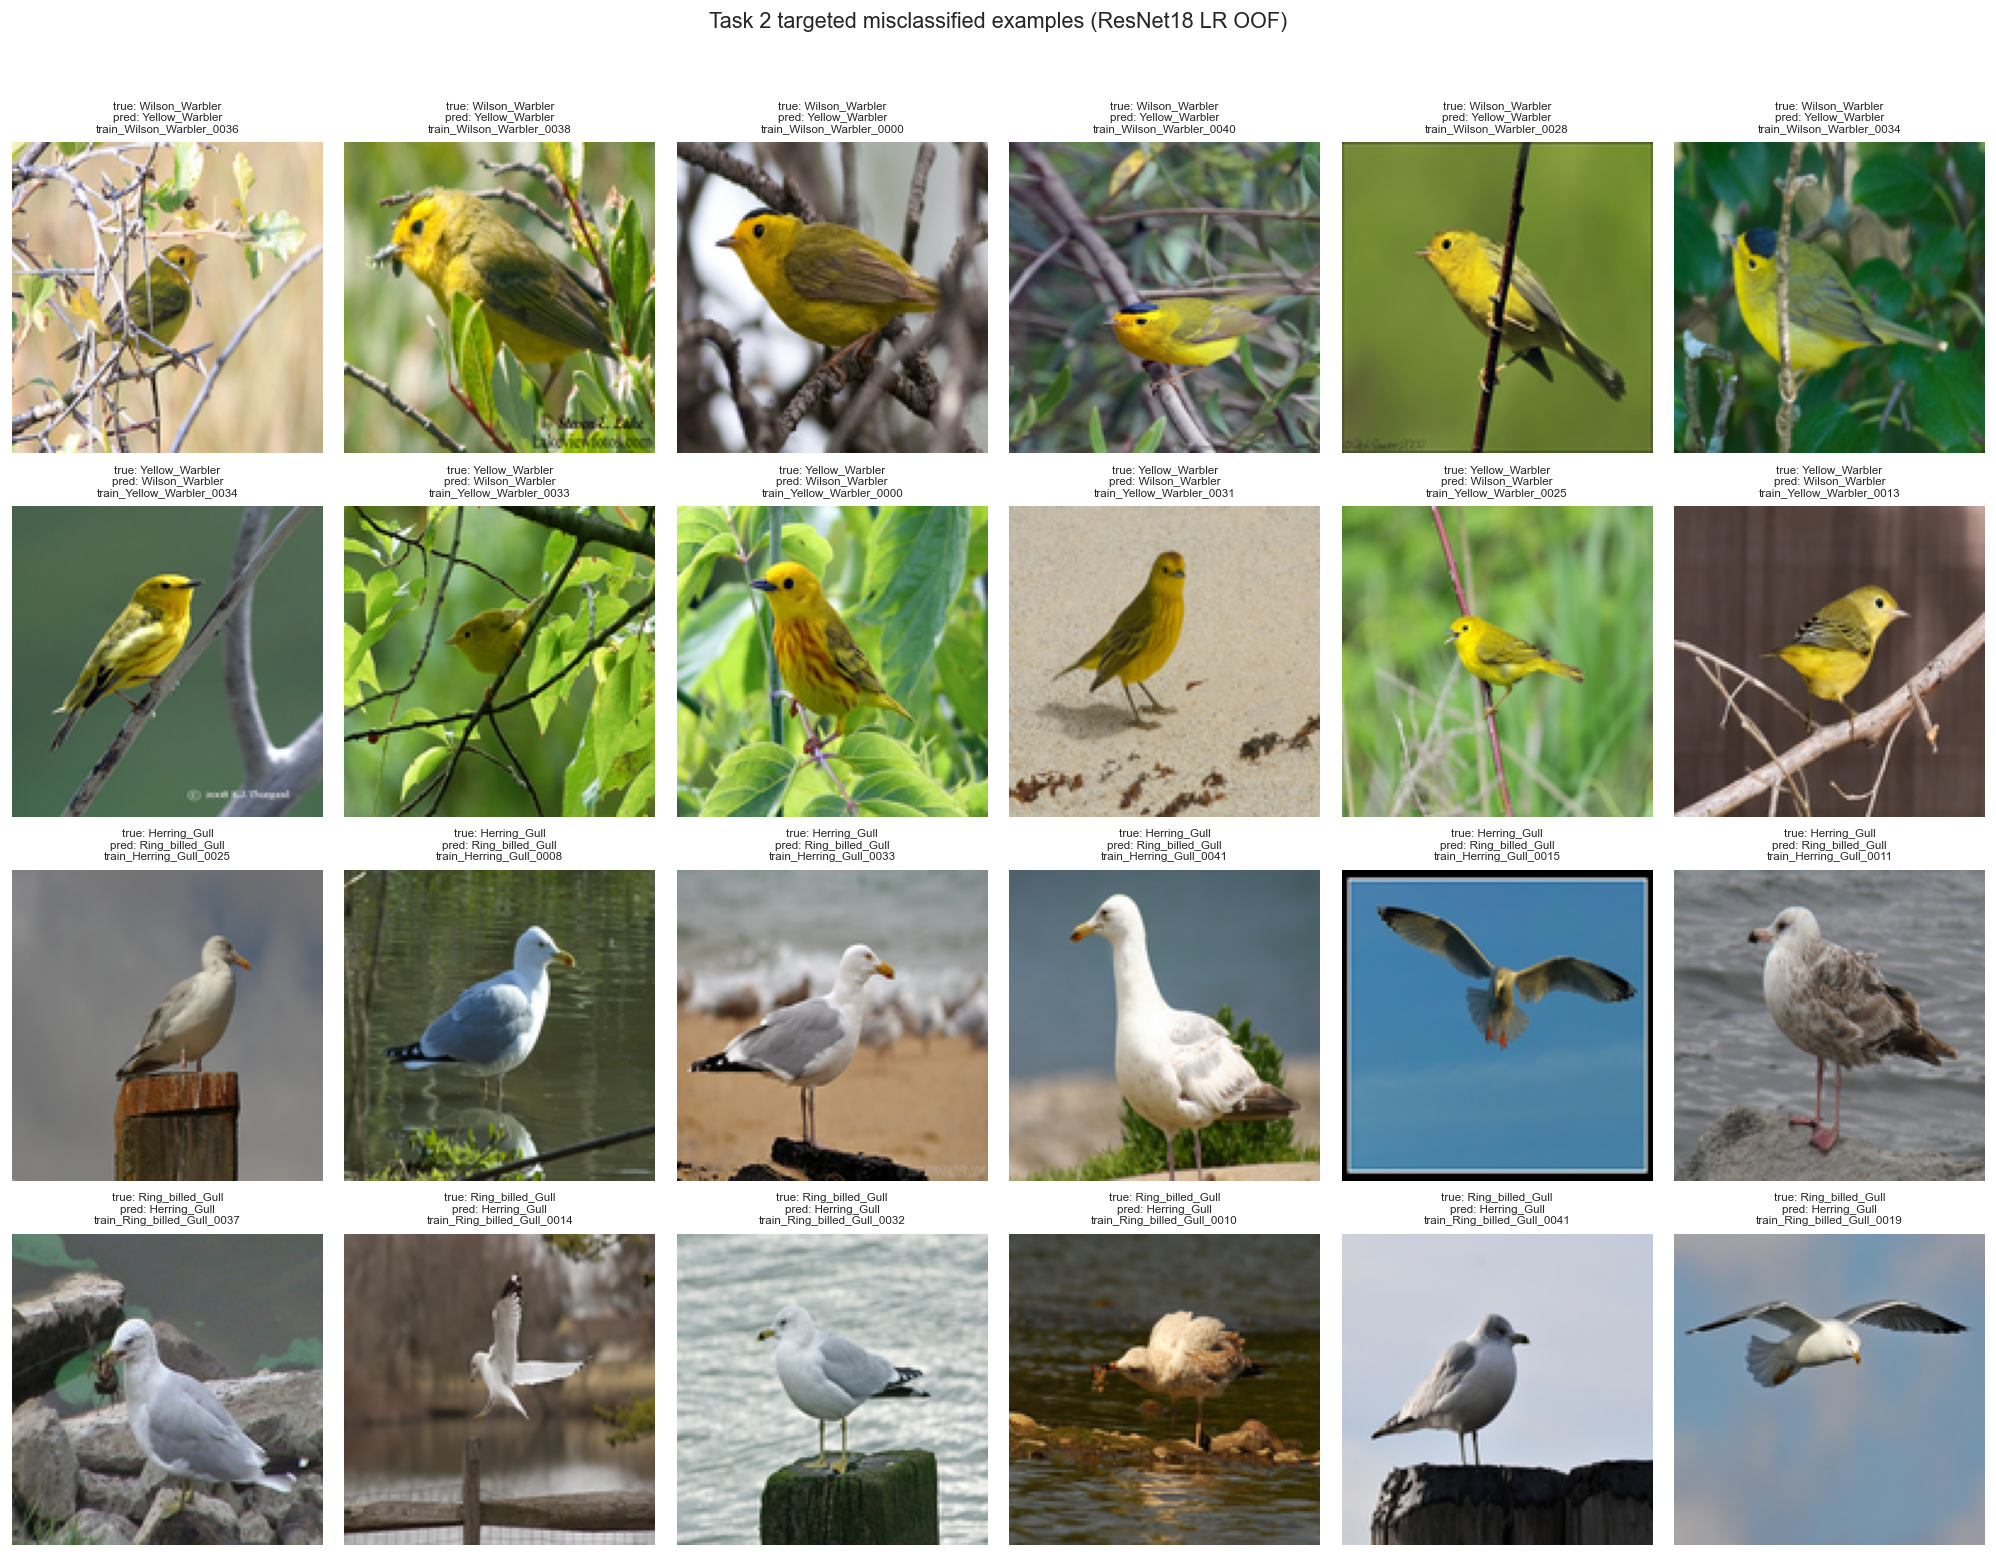

Saved /Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/task2_targeted_misclassified_examples.png


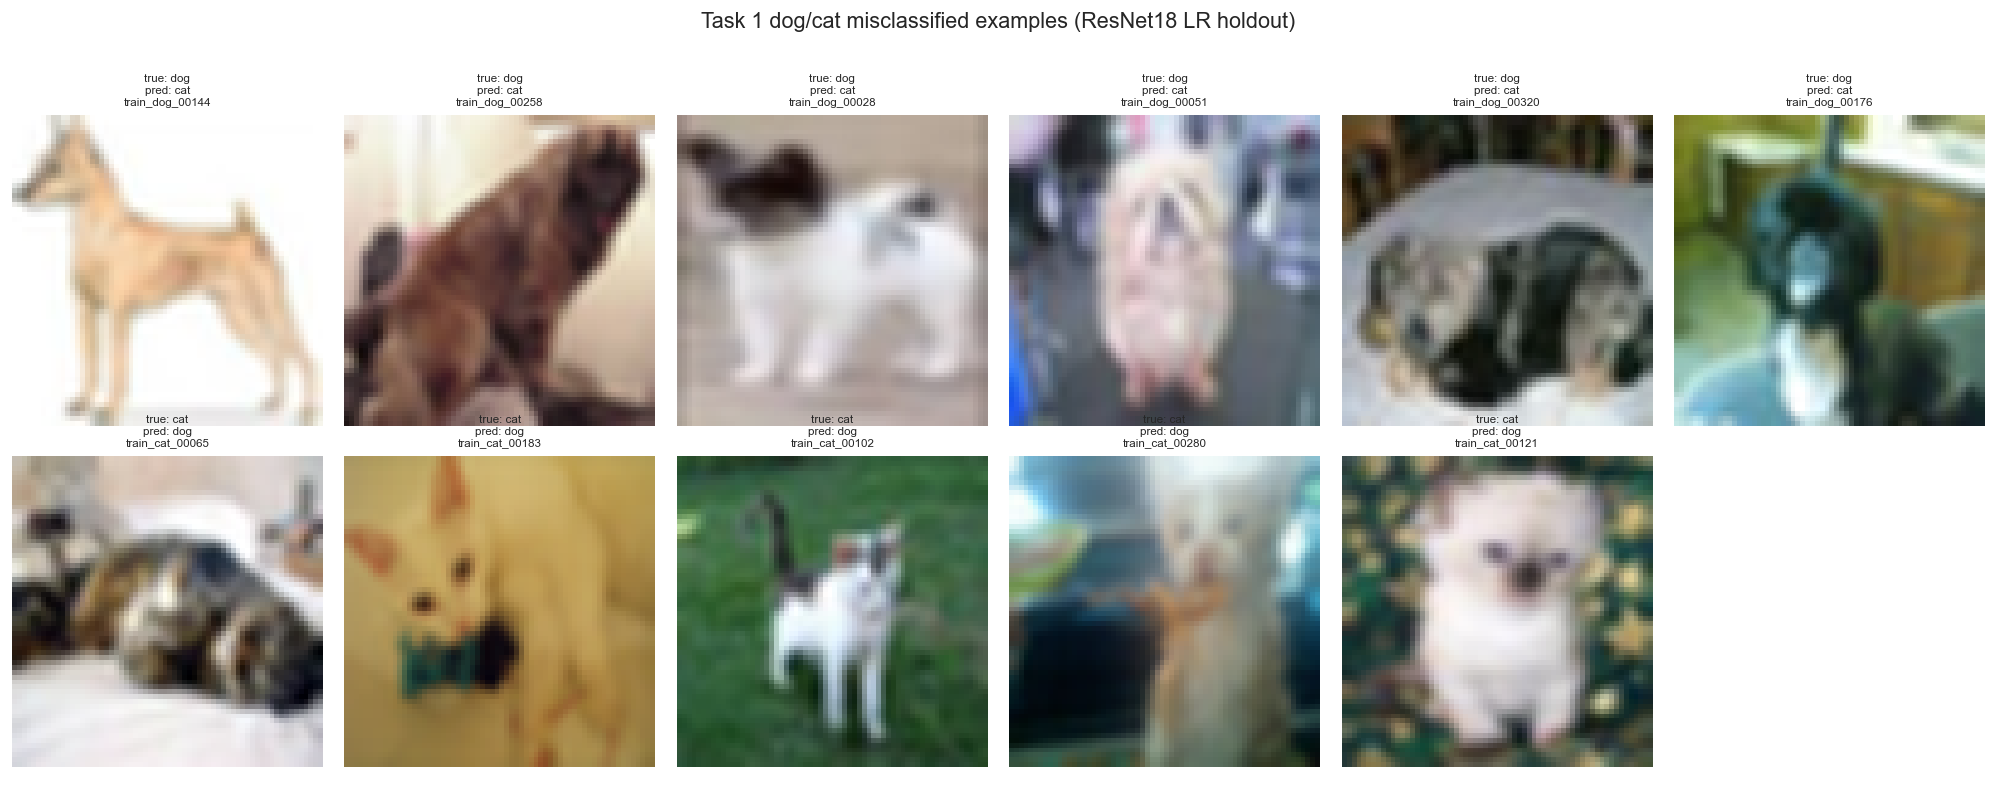

Saved /Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/task1_dog_cat_misclassified_examples.png


PosixPath('/Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/task1_dog_cat_misclassified_examples.png')

In [10]:
# Additional misclassified-image grids for manual visual analysis


def class_id_by_name(class_map: pd.DataFrame, name: str) -> int:
    matches = class_map.loc[class_map["class_name"] == name, "class_id"]
    if matches.empty:
        raise ValueError(f"Class name not found: {name}")
    return int(matches.iloc[0])


def plot_misclassified_examples(
    meta: pd.DataFrame,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_map: pd.DataFrame,
    pairs: list[tuple[str, str]],
    task_dir: Path,
    out_path: Path,
    title: str,
    max_per_pair: int = 6,
):
    meta = meta.reset_index(drop=True).copy()
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rows = []
    for true_name, pred_name in pairs:
        true_id = class_id_by_name(class_map, true_name)
        pred_id = class_id_by_name(class_map, pred_name)
        subset = meta[(y_true == true_id) & (y_pred == pred_id)].copy()
        if len(subset) == 0:
            continue
        rows.append((true_name, pred_name, subset.sample(n=min(max_per_pair, len(subset)), random_state=SEED)))

    if not rows:
        print(f"No misclassified examples found for {title}")
        return None

    fig, axes = plt.subplots(
        len(rows),
        max_per_pair,
        figsize=(2.8 * max_per_pair, 3.2 * len(rows)),
        squeeze=False,
    )
    fig.suptitle(title, y=1.02, fontsize=13)

    for row_idx, (true_name, pred_name, picks) in enumerate(rows):
        for col in range(max_per_pair):
            ax = axes[row_idx, col]
            ax.axis("off")
            if col >= len(picks):
                continue

            row = picks.iloc[col]
            with Image.open(task_dir / row["image_path"]) as im:
                ax.imshow(im.convert("RGB"))
            ax.set_title(
                f"true: {true_name}\npred: {pred_name}\n{row['image_id']}",
                fontsize=7,
            )

        axes[row_idx, 0].set_ylabel(
            f"{true_name}\nmisread as\n{pred_name}",
            fontsize=8,
            rotation=0,
            labelpad=46,
            va="center",
        )

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")
    return out_path


# Task 2: targeted fine-grained bird confusions mentioned in the report text.
task2_pairs_to_inspect = [
    ("Wilson_Warbler", "Yellow_Warbler"),
    ("Yellow_Warbler", "Wilson_Warbler"),
    ("Herring_Gull", "Ring_billed_Gull"),
    ("Ring_billed_Gull", "Herring_Gull"),
]

plot_misclassified_examples(
    meta=task2.train_meta,
    y_true=y2,
    y_pred=y2_cnn_pred,
    class_map=class_map2,
    pairs=task2_pairs_to_inspect,
    task_dir=task2.task_dir,
    out_path=OUT_DIR / "task2_targeted_misclassified_examples.png",
    title="Task 2 targeted misclassified examples (ResNet18 LR OOF)",
)


# Task 1: dog/cat confusions on the same holdout split used above.
_, task1_val_idx, _, _ = stratified_split(
    np.arange(len(y1)),
    y1,
    test_size=0.2,
    seed=SEED,
)
task1_val_meta = task1.train_meta.iloc[task1_val_idx].reset_index(drop=True)
assert np.array_equal(task1_val_meta["class_id"].to_numpy(), y1_val)

task1_pairs_to_inspect = [
    ("dog", "cat"),
    ("cat", "dog"),
]

plot_misclassified_examples(
    meta=task1_val_meta,
    y_true=y1_val,
    y_pred=y1_cnn_pred,
    class_map=class_map1,
    pairs=task1_pairs_to_inspect,
    task_dir=task1.task_dir,
    out_path=OUT_DIR / "task1_dog_cat_misclassified_examples.png",
    title="Task 1 dog/cat misclassified examples (ResNet18 LR holdout)",
)


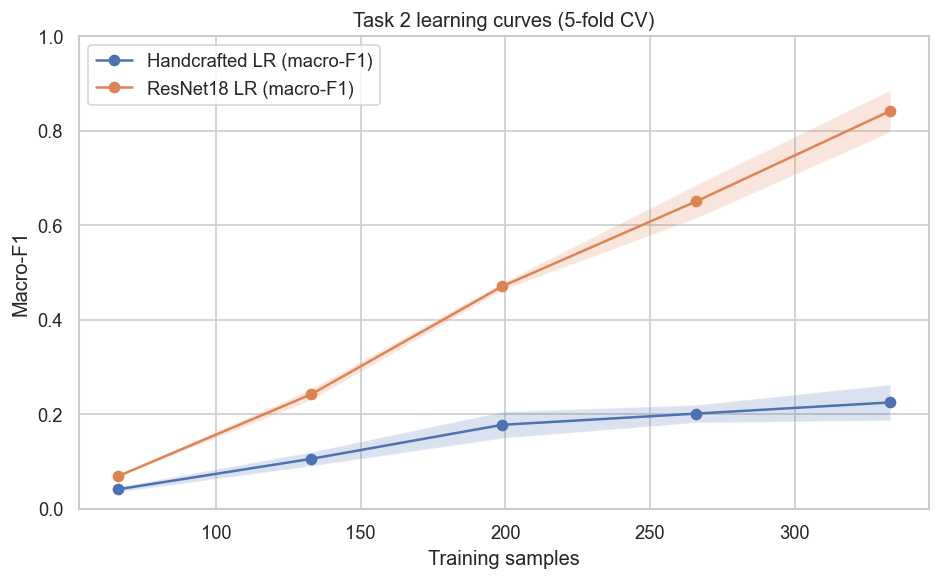

Saved /Users/ericzhang/uni/ml/MLAssignment2/outputs/figures/error_analysis/task2_learning_curve.png


,comparison,handcrafted_lr,resnet18_lr
0,Task 1 holdout macro-F1,0.542142,0.865104
1,Task 2 CV macro-F1,0.221725,0.840798


In [11]:
# Task 2 learning curves: handcrafted LR vs ResNet18 LR

train_sizes = np.linspace(0.2, 1.0, 5)
cv = kfold(5, seed=SEED)

hand_est = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2500, C=1.0, solver="lbfgs", random_state=SEED)),
])
cnn_est = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs", random_state=SEED)),
])

sizes_h, _, val_h = learning_curve(
    hand_est,
    X2,
    y2,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

sizes_c, _, val_c = learning_curve(
    cnn_est,
    X2_resnet,
    y2,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes_h, val_h.mean(axis=1), marker="o", label="Handcrafted LR (macro-F1)")
ax.plot(sizes_c, val_c.mean(axis=1), marker="o", label="ResNet18 LR (macro-F1)")
ax.fill_between(sizes_h, val_h.mean(axis=1) - val_h.std(axis=1), val_h.mean(axis=1) + val_h.std(axis=1), alpha=0.2)
ax.fill_between(sizes_c, val_c.mean(axis=1) - val_c.std(axis=1), val_c.mean(axis=1) + val_c.std(axis=1), alpha=0.2)
ax.set_title("Task 2 learning curves (5-fold CV)")
ax.set_xlabel("Training samples")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
lc_path = OUT_DIR / "task2_learning_curve.png"
fig.savefig(lc_path, bbox_inches="tight")
plt.show()
print(f"Saved {lc_path}")

summary = pd.DataFrame([
    {
        "comparison": "Task 1 holdout macro-F1",
        "handcrafted_lr": m1_hand["macro_f1"],
        "resnet18_lr": m1_cnn["macro_f1"],
    },
    {
        "comparison": "Task 2 CV macro-F1",
        "handcrafted_lr": m2_hand["macro_f1"],
        "resnet18_lr": m2_cnn["macro_f1"],
    },
])
summary